# Notebook \#1:</br> Data Wrangling and Feature Engineering

## 01 - Setup

In [1]:
import os
import requests
import re
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from io import StringIO
from datetime import datetime, timedelta
from haversine import haversine, Unit
from dotenv import load_dotenv
from typing import List, Tuple

load_dotenv(override=True)  # Loads environment variables

# Constants
FROST_CLIENT_ID = os.getenv("FROST_API_CLIENT_ID")
DMI_MET_OBS_API_KEY = os.getenv("DMI_MET_OBS_API_KEY")
DMI_STATIONS_API = "https://dmigw.govcloud.dk/v2/metObs/collections/station/items"
SMHI_STATIONS_API = f"https://opendata-download-metobs.smhi.se/api/version/latest/parameter/1/station.json"  # Parameter 1 = Temperature


In [2]:
# Sets notebook settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

The dataset is a multivariate time series organized by electric vehicle (EV) charging sessions, where each session has been given a unique ID. Within each session, the data is regularly sampled at one-minute intervals, capturing the time-dependent variables `soc`, `power` and `energy`. Additionally, sessions include variables that remain constant (static) throughout the session, such as `charger_category` and `nominal_power`. This structure aligns with the statistical definition of <a href="https://en.wikipedia.org/wiki/Panel_data">panel data</a>, as it combines cross-sectional dimensions (e.g., multiple chargers or sessions) with time-series dimensions, grouped by entities (`charging_id`).

In [3]:
# Loads the raw dataset
df = pd.read_parquet("../Data/etron55-charging-sessions-raw-nov-24.parquet")
all_columns = ["charging_id", "timestamp", "power", "soc", "energy",\
               "charging_duration", "charger_category", "nominal_power", "lat", "lon"]
df = df[all_columns]
df.head()

,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
0,0,2020-01-11 12:37:21,89.44,40.0,0.32,23,Ultra,150.0,59.668262,9.652725
1,0,2020-01-11 12:38:21,92.75,41.0,1.84,23,Ultra,150.0,59.668262,9.652725
2,0,2020-01-11 12:39:21,94.81,43.0,3.41,23,Ultra,150.0,59.668262,9.652725
3,0,2020-01-11 12:40:21,95.68,45.0,5.00,23,Ultra,150.0,59.668262,9.652725
4,0,2020-01-11 12:41:21,96.88,47.0,6.60,23,Ultra,150.0,59.668262,9.652725


In [4]:
# Displays the dataset's size, columns, number of missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1643654 entries, 0 to 1643653
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   charging_id        1643654 non-null  int64         
 1   timestamp          1643654 non-null  datetime64[ns]
 2   power              1643654 non-null  float64       
 3   soc                1643654 non-null  float64       
 4   energy             1643654 non-null  float64       
 5   charging_duration  1643654 non-null  int64         
 6   charger_category   1643654 non-null  object        
 7   nominal_power      1643654 non-null  float64       
 8   lat                1643654 non-null  float64       
 9   lon                1643654 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 125.4+ MB


The dataset does not contain any invalid values, such as `np.nan`, `pd.NA`, `pd.NAT`, and `None`.

#### Explanation of variables in the dataset
The dataset contains 1,643,654 measurements divided into 62,422 distinct charging sessions </br>for the Audi E-tron 55 EV. Each charging session was recorded at one of <a href="https://www.eviny.no/">Eviny</a>'s 286 charging stations. </br>
 - **`charging_id`, categorical, static (per session):**  The identifier for the entire charging session. A charging session is a single car, charging once at a single charging station. </br>
  - **`timestamp`, DateTime, piecewise continuous:** The date and time of each measurement (YYYY-mm-dd HH:MM:SS). The time-dependent variables are measured at one minute intervals. </br>
   - **`power`, numerical, piecewise continuous, time-dependent:** The current power output in kW from the charging station to the car. </br>
 - **`soc`, numerical, piecewise continuous, time-dependent**: The State of Charge (SOC) of the car\'s battery as a percentage </br>
 - **`energy`, numerical, piecewise continuous, time-dependent:** The aggregate power delivered to the car in kWh over the course of the charging session. </br>
  - **`charging_duration`, numerical, discrete, static (per session):** How many minutes the charging session lasted. </br>
 - **`charger_category`, categorical, static (per session):** What type of charging station is being used to provide power to the vehicle. Values are *Ultra* or *Rapid*.
 - **`nominal_power`, ordinal, static (per session):** The maximum (nominal) power output in kW for the charging station. There are 22 different values ranging from 50 to 500 kW. </br>
 - **`lat`, numerical, continuous, static (per session):** The latitude of the charging station. </br>
 - **`lon`, numerical, continuous, static (per session):** The longitude of the charging station.</br>
 <i>PS: Some of the descriptive metrics above were calculated in the <a href="https://github.com/SebastianRokholt/Machine-Teaching-for-XAI--TimeSeries-Models/blob/main/Notebooks/02__EDA.ipynb">EDA notebook</a>.</i>

----
## 02 - Data Wrangling

In [5]:
# Sets appropriate data types
df['charging_id'] = df['charging_id'].astype(int)
df["nominal_power"] = df["nominal_power"].astype(int)
df["charger_category"] = df["charger_category"].astype("category")

# Ensure the data are sorted by timestamp per session
df = df.sort_values(by=['charging_id', 'timestamp'])

To ensure that we have a consistent sampling rate of one reading per minute for all of the charging sessions, we will now check whether there are any missing readings by grouping the dataset on `charging_id` and calculating the difference between the expected and actual number of readings for each session. I.e. a charging session that lasted for 20 minutes should have 21 readings (rows) that correspond to that session's charging ID. We will also verify whether the `charging_duration` value provided by Eviny matches the actual duration of the session. 

In [6]:
# Group by charging_id and calculate required metrics
session_stats = (
    df.groupby('charging_id')
    .agg(
        first_timestamp=('timestamp', 'min'),
        last_timestamp=('timestamp', 'max'),
        actual_readings=('timestamp', 'count'),
        charging_duration=('charging_duration', 'first')
    )
    .reset_index()
)

# Calculate expected vs actual number of readings, which gives us the number of missing readings, 
# where a negative integer tells us that there are more readings than we expected
session_stats['expected_readings'] = (
    (session_stats['last_timestamp'] - session_stats['first_timestamp']).dt.total_seconds() // 60 + 1
).astype(int)
session_stats['n_missing_readings'] = session_stats['expected_readings'] - session_stats['actual_readings']
# Calculate the extra/missing readings per session as a percentage of number of expected readings
session_stats['extra_or_missing_percentage'] = (
    session_stats['n_missing_readings'] / session_stats['expected_readings']
) * 100
session_stats['duration_mismatch'] = (session_stats['expected_readings'] != session_stats['charging_duration'])

# We will also check whether the `charging_duration` value provided by Eviny matches the data for the session
mismatched_sessions_count = session_stats['duration_mismatch'].sum()

print("The head of the DataFrame with the calculated metrics:")
display(session_stats.head())

The head of the DataFrame with the calculated metrics:


,charging_id,first_timestamp,last_timestamp,actual_readings,charging_duration,expected_readings,n_missing_readings,extra_or_missing_percentage,duration_mismatch
0,0,2020-01-11 12:37:21,2020-01-11 12:59:21,23,23,23,0,0.0,False
1,4084,2020-01-14 12:44:11,2020-01-14 13:03:11,20,21,20,0,0.0,True
2,9323,2020-01-18 10:17:54,2020-01-18 10:56:54,40,40,40,0,0.0,False
3,11921,2020-01-19 19:10:14,2020-01-19 19:30:14,21,21,21,0,0.0,False
4,17906,2020-01-24 06:44:11,2020-01-24 07:21:11,38,38,38,0,0.0,False


In [7]:
print(f"Total number of charging sessions: {len(session_stats)}")
print(f"Number of charging sessions with duration mismatch: {mismatched_sessions_count}")
sessions_with_missing_readings = session_stats[session_stats["n_missing_readings"] > 0]
sessions_with_extra_readings = session_stats[session_stats["n_missing_readings"] < 0]
print(f"Number of charging sessions with missing readings: {len(sessions_with_missing_readings)}")
print(f"Number of charging sessions with extra readings: {len(sessions_with_extra_readings)}")

Total number of charging sessions: 62422
Number of charging sessions with duration mismatch: 16227
Number of charging sessions with missing readings: 1153
Number of charging sessions with extra readings: 14090


It is apparent that the `charging_duration` values provided by Eviny don't always match the charging session's duration between the first and the last timesteps. Going forward, we will therefore not be using this variable. Furthermore, we can see that there is a large number (14090) of charging sessions that have extra readings, while a smaller but significant portion (1153) have missing readings. We will investigate this issue further by plotting the distribution of the number of extra and missing values. 

In [8]:
# Removes the `charging_duration` variable from the dataset
df = df.drop(columns=["charging_duration"])
all_columns.remove("charging_duration")

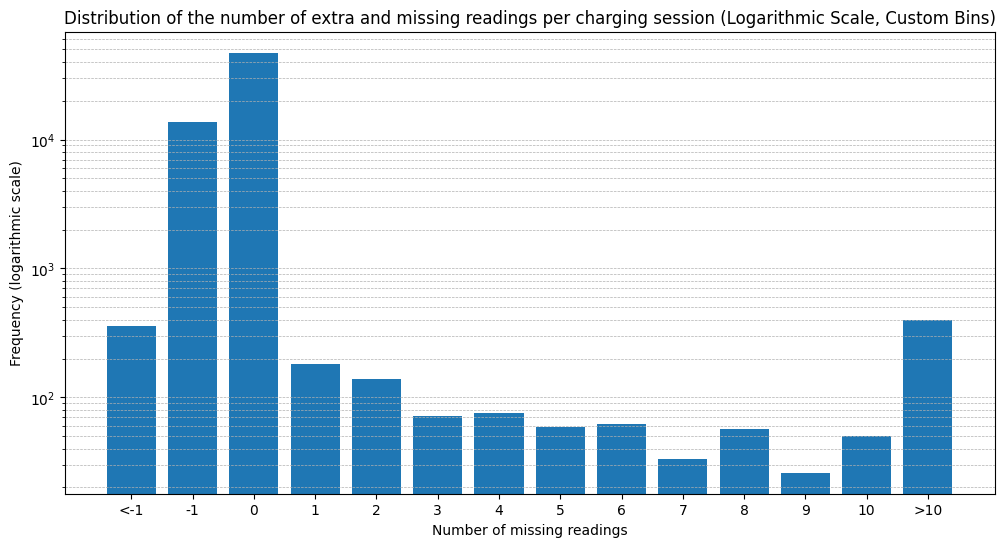

In [9]:
# Calculates the value counts of missing readings per charging session
missing_readings_counts = session_stats['n_missing_readings'].value_counts().sort_index()

# Defines custom histogram bins s.t. the counts <-1 and >10 are binned
binned_counts = {
    '<-1': missing_readings_counts[missing_readings_counts.index < -1].sum(),
    **missing_readings_counts[(missing_readings_counts.index >= -1) & (missing_readings_counts.index <= 10)].to_dict(),
    '>10': missing_readings_counts[missing_readings_counts.index > 10].sum()
}
binned_categories = [str(key) for key in binned_counts.keys()]  # Keys must be strings to avoid plotting TypeError
binned_values = list(binned_counts.values())

# Plot with logarithmic y-axis
plt.figure(figsize=(12, 6))
plt.bar(binned_categories, binned_values, log=True)
plt.title('Distribution of the number of extra and missing readings per charging session (Logarithmic Scale, Custom Bins)')
plt.xlabel('Number of missing readings')
plt.ylabel('Frequency (logarithmic scale)')
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
plt.show()



For the charging sessions that have extra readings, we can resample the session to per-minute readings by taking the mean value within the same minute. Most of the sessions that have missing readings only have a few readings missing, so we can keep these in the dataset by interpolating the missing values. Charging sessions that have a large number of missing readings should be discarded, as there is no point in training a model on charging sessions that have many interpolated values. However, since the dataset contains charging sessions of variable lengths, we want to make the decision on which sessions to keep or discard based on the number of missing readings as a percentage of expected readings. 

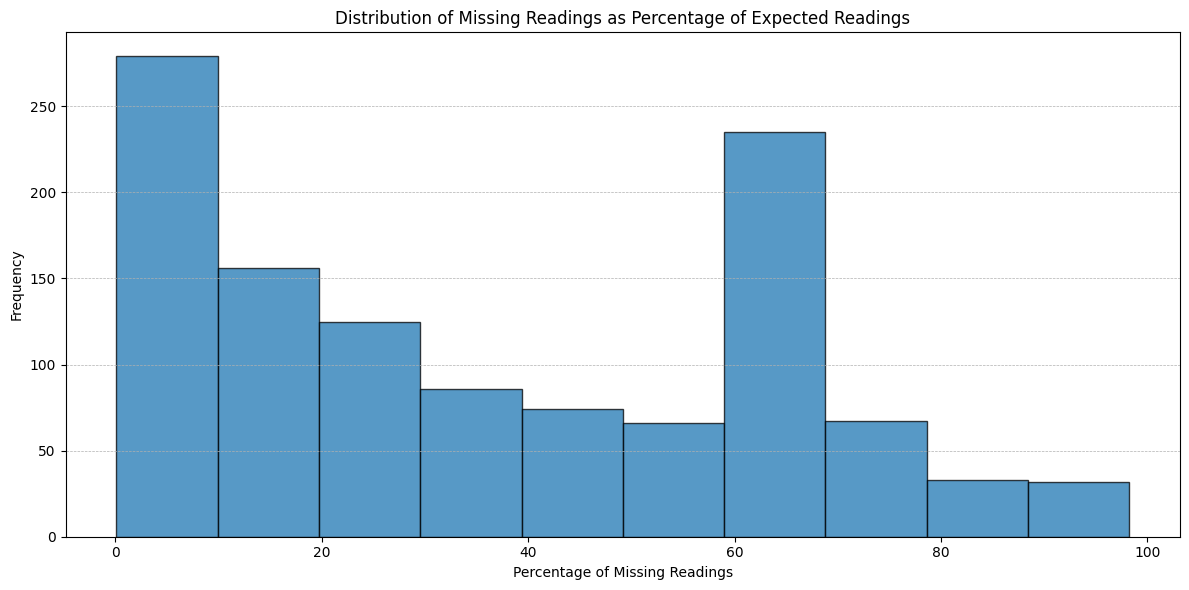

In [10]:
# Filter for sessions with missing readings (negative percentages only)
missing_readings_data = session_stats['extra_or_missing_percentage'][session_stats['extra_or_missing_percentage'] > 0]

# Define more bins for finer granularity
bins = np.linspace(0.1, missing_readings_data.max(), 11)  # 50 bins between the minimum and 0

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(missing_readings_data, bins=bins, alpha=0.75, edgecolor='black')
plt.title('Distribution of Missing Readings as Percentage of Expected Readings')
plt.xlabel('Percentage of Missing Readings')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

Of the 1153 charging sessions that have missing readings, more than 400 of them have less than 20% missing readings. We will keep these and discard the others. 

In [11]:
# Filter sessions based on the threshold of <20% missing readings
threshold = 20
valid_sessions = session_stats[
    session_stats['extra_or_missing_percentage'] <= threshold
]['charging_id']

# Keep only valid sessions in the original dataset
df = df[df['charging_id'].isin(valid_sessions)]
n_remaining_sessions = len(df["charging_id"].unique())

assert len(valid_sessions) == n_remaining_sessions
print(f"Total number of charging sessions: {len(session_stats)}")
print(f"Remaining charging sessions after removing {len(session_stats) - n_remaining_sessions} "
      f"sessions: {n_remaining_sessions}")

Total number of charging sessions: 62422
Remaining charging sessions after removing 697 sessions: 61725


Since we used the duration between the first and last timestamps in the session to determine the amount of expected readings, the filtering technique above doesn't catch sessions that only have a single reading. Since we don't know whether the single reading is at the beginning, in the middle, or at the end of the session, these sessions - if any - must be discarded. 

In [12]:
single_readings_df = session_stats[session_stats["expected_readings"] == 1]
single_readings_df

,charging_id,first_timestamp,last_timestamp,actual_readings,charging_duration,expected_readings,n_missing_readings,extra_or_missing_percentage,duration_mismatch
60463,12219954,2024-09-14 09:06:53,2024-09-14 09:06:53,1,60,1,0,0.0,True


In [13]:
# Removes sessions with only one expected / actual reading
single_reading_ids = single_readings_df["charging_id"]
df = df[~df["charging_id"].isin(single_reading_ids)]
print(f"Removed {len(single_reading_ids)} reading(s) from the dataset.")

Removed 1 reading(s) from the dataset.


### Handling missing and extra readings 
We will now perform re-sampling on the charging sessions with extra readings, and handle the remaining sessions with missing readings. The non-static time-dependent numerical features `soc`, `power`, `energy` and the static features(`charger_category`, `nominal_power`, `lat`, `lon`) must be handled seperately. 

#### Handling non-static time-dependent numerical features: 
For the extra values in the piecewise time-dependent numerical variables we perform mean resampling s.t. when there are multiple readings within the same minute, we keep the mean of these values. For time intervals that have missing readings, the resampling will create empty rows with NaN values, which we will then handle with linear interpolation. This is because it is reasonable to assume that for small time intervals, `power`, `soc` and `energy` behaves more or less linearly. 

#### Handling static features:
For the extra static featues we perform resampling with forward-filling, s.t. when there are multiple readings within the same minute, we keep the first occurring value. This will also handle time intervals with missing readings, as the `.ffill()` method is called directly after resampling. However, as there might be instances where the first reading contains a NaN value which is propagated forward, we will also perform backwards-filling in order to ensure that the static values are consistent across each charging session.

In [14]:
df_with_time_index = df.set_index("timestamp")

# Function to resample and a handle missing data for a single session
def resample_and_interpolate_session(session):
    # Numerical features: Mean resampling to handle extra readings + linear interpolation to handle missing
    numerical_resampled = session[['soc', 'power', 'energy']].resample('min').mean()
    numerical_resampled = numerical_resampled.interpolate(method='linear')
    # Static features: Forward fill to handle extra readings + forward fill again for missing readings
    static_resampled = session[['charger_category', 'nominal_power', 'lat', 'lon']].resample('min').ffill()
    static_resampled = static_resampled.ffill().bfill()

    # Combine the resampled data
    resampled = pd.concat([numerical_resampled, static_resampled], axis=1)
    return resampled

# Groups by charging_id and resample each session
resampled_sessions = []
for charging_id, session in df_with_time_index.groupby('charging_id'):
    resampled_session = resample_and_interpolate_session(session)
    resampled_session['charging_id'] = charging_id  # Reintroduce the charging_id column
    resampled_sessions.append(resampled_session)

# Combines all resampled sessions into one DataFrame
resampled_df = pd.concat(resampled_sessions)
resampled_df = resampled_df.reset_index()
df = resampled_df[all_columns]
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1616588 entries, 0 to 1616587
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   charging_id       1616588 non-null  int64         
 1   timestamp         1616588 non-null  datetime64[ns]
 2   power             1616588 non-null  float64       
 3   soc               1616588 non-null  float64       
 4   energy            1616588 non-null  float64       
 5   charger_category  1616588 non-null  category      
 6   nominal_power     1616588 non-null  float64       
 7   lat               1616588 non-null  float64       
 8   lon               1616588 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(6), int64(1)
memory usage: 100.2 MB


### Handling `power` readings that are 0
We have previously seen that the dataset does not contain any missing data in terms of invalid values (e.g. `np.nan`, `pd.NA`, `pd.NAT`, `None`). However, there are still missing values in the `power` column, if we define a reading of `0` kW to be a missing value when it occurs at the beginning or the end of a charging session. These zero readings occur because the charging station starts recording data from the session before any power is delivered to the vehicle, and immediately after the the charger is disconnected. We have decided to remove these leading and trailing zeros from the dataset, as they do not contain any valid information about the normality of the charging session, and thus might introduce unwanted noise to the training data.

In [16]:
# Calculates and displays the number of rows where the power output is zero
rows_with_zeros = df[df["power"] == 0]
print(f"There are {len(rows_with_zeros)} rows where the power output is zero.")
zeros_indices = rows_with_zeros.head().index  # Selects the index of five of these rows
print("First five rows with 0 in 'power' and their neighbors:\n")
for idx in zeros_indices:
    # Get two preceding and two succeeding rows
    start = max(0, idx - 2)
    end = min(len(df), idx + 3)
    neighbors = df.iloc[start:end]
    print(f"--- Rows around index {idx} ---")
    display(neighbors)

There are 27188 rows where the power output is zero.
First five rows with 0 in 'power' and their neighbors:

--- Rows around index 82 ---


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
80,9323,2020-01-18 10:54:00,41.77,98.0,57.16,Ultra,150.0,59.856422,10.660129
81,9323,2020-01-18 10:55:00,34.05,98.0,57.76,Ultra,150.0,59.856422,10.660129
82,9323,2020-01-18 10:56:00,0.00,100.0,58.26,Ultra,150.0,59.856422,10.660129
83,11921,2020-01-19 19:10:00,94.05,39.0,0.23,Rapid,100.0,60.192920,5.464906
84,11921,2020-01-19 19:11:00,98.70,41.0,1.86,Rapid,100.0,60.192920,5.464906


--- Rows around index 141 ---


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
139,17906,2020-01-24 07:19:00,95.94,77.0,55.31,Ultra,150.0,60.797527,5.010914
140,17906,2020-01-24 07:20:00,95.94,79.0,56.91,Ultra,150.0,60.797527,5.010914
141,17906,2020-01-24 07:21:00,0.00,80.0,57.25,Ultra,150.0,60.797527,5.010914
142,29836,2020-01-31 20:56:00,89.13,15.0,0.22,Ultra,150.0,62.074738,9.127917
143,29836,2020-01-31 20:57:00,93.92,17.0,1.76,Ultra,150.0,62.074738,9.127917


--- Rows around index 249 ---


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
247,39929,2020-02-07 18:37:00,96.64,83.0,36.90,Ultra,150.0,60.986538,9.238304
248,39929,2020-02-07 18:38:00,91.07,85.0,38.46,Ultra,150.0,60.986538,9.238304
249,40043,2020-02-07 19:14:00,0.00,16.0,0.00,Rapid,50.0,60.739820,5.633132
250,40043,2020-02-07 19:15:00,48.98,17.0,0.67,Rapid,50.0,60.739820,5.633132
251,40043,2020-02-07 19:16:00,48.31,18.0,1.48,Rapid,50.0,60.739820,5.633132


--- Rows around index 385 ---


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
383,53363,2020-02-16 14:21:00,47.60,98.0,45.97,Ultra,150.0,60.701756,8.962077
384,53363,2020-02-16 14:22:00,35.07,98.0,46.71,Ultra,150.0,60.701756,8.962077
385,53363,2020-02-16 14:23:00,0.00,100.0,47.17,Ultra,150.0,60.701756,8.962077
386,54941,2020-02-17 15:21:00,101.34,37.0,0.28,Ultra,150.0,61.488100,6.081220
387,54941,2020-02-17 15:22:00,106.14,40.0,2.01,Ultra,150.0,61.488100,6.081220


--- Rows around index 450 ---


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
448,59415,2020-02-20 16:20:00,86.66,78.0,25.12,Ultra,150.0,58.847748,5.738282
449,59415,2020-02-20 16:21:00,86.75,79.0,26.56,Ultra,150.0,58.847748,5.738282
450,59991,2020-02-20 20:18:00,0.00,23.0,0.00,Rapid,50.0,59.668262,9.652725
451,59991,2020-02-20 20:19:00,49.20,24.0,0.68,Rapid,50.0,59.668262,9.652725
452,59991,2020-02-20 20:20:00,49.32,25.0,1.51,Rapid,50.0,59.668262,9.652725


It seems that most of these zero outputs occur at the beginning (leading) or at the end (trailing) of the charging session. These zeros can be removed, but if there are zeros in the middle of a session, we want to keep them as they might be an indicator of a problem with the vehicle's battery or the charger.

In [17]:
def trim_zeros_from_power_output(df: pd.DataFrame) -> pd.DataFrame:
    indices_to_drop = []

    # Groups the DataFrame by session id
    for _, group in df.groupby("charging_id"):
        values = group["power"].values
        indices = group.index.values

        # Finds the index of the first non-zero row with next, as it is more memory efficient than simple indexing
        first_nonzero_idx = next((i for i, val in enumerate(values) if val != 0), None)
        if first_nonzero_idx is None:  # all values are zero and can be dropped
            indices_to_drop.extend(indices)
            continue

        # Find the last non-zero index
        last_nonzero_idx = len(values) - 1 - next((i for i, val in enumerate(values[::-1]) if val != 0), None)

        # Indices to keep are between first_nonzero_idx and last_nonzero_idx inclusive
        indices_to_keep = indices[first_nonzero_idx:last_nonzero_idx+1]

        # Indices to drop are before the first non-zero and after the last non-zero
        indices_to_drop_group = list(set(indices) - set(indices_to_keep))
        indices_to_drop.extend(indices_to_drop_group)

    # Drop the identified rows from the DataFrame
    df_trimmed = df.drop(indices_to_drop)
    return df_trimmed

# Apply the function to your DataFrame
df_trimmed = trim_zeros_from_power_output(df)

# Display the trimmed DataFrame
print(f"Trimmed {len(df) - len(df_trimmed)} rows with leading or trailing zero for power output column.")
df_trimmed.head()

Trimmed 26444 rows with leading or trailing zero for power output column.


,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725


In [18]:
remaining_zeros = len(df_trimmed[df_trimmed["power"]==0])
print(f"There are still {remaining_zeros} rows left where the power output is zero, but these values are not leading or trailing.")
df = df_trimmed.copy()

There are still 744 rows left where the power output is zero, but these values are not leading or trailing.


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1590144 entries, 0 to 1616586
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   charging_id       1590144 non-null  int64         
 1   timestamp         1590144 non-null  datetime64[ns]
 2   power             1590144 non-null  float64       
 3   soc               1590144 non-null  float64       
 4   energy            1590144 non-null  float64       
 5   charger_category  1590144 non-null  category      
 6   nominal_power     1590144 non-null  float64       
 7   lat               1590144 non-null  float64       
 8   lon               1590144 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(6), int64(1)
memory usage: 110.7 MB


In [20]:
df.isna().sum()

charging_id         0
timestamp           0
power               0
soc                 0
energy              0
charger_category    0
nominal_power       0
lat                 0
lon                 0
dtype: int64

## 03 - Feature Engineering

#### Converting `timestamp` to `minutes_elapsed`
Since the temporal nature of each charging session...

In [21]:
df['minutes_elapsed'] = df.groupby('charging_id')['timestamp']\
    .transform(lambda x: (x - x.min()).dt.total_seconds() // 60)
df['minutes_elapsed'] = df['minutes_elapsed'].astype(int)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4


#### Adding temperature data to each session

A location given with latitude and longitude with 6 decimal places is accurate down to a radius of 11 cm, so 2 decimal places (accurate down to 1.1km) is more than accurate enough for the purpose of retrieving a temperature reading from the nearest weather station.

In [22]:
df["lat"] = df["lat"].round(2)
df["lon"] = df["lon"].round(2)

In [23]:
# Converts the timestamp to the Frost-specified format, with granularity of 1 hour
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_H'] = df.groupby('charging_id')['timestamp'].transform('first')
df['timestamp_H'] = df['timestamp_H'].dt.strftime('%Y-%m-%dT%H')
df['timestamp_d'] = df.groupby('charging_id')['timestamp'].transform('first')
df['timestamp_d'] = df['timestamp_d'].dt.strftime('%Y-%m-%d')
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,timestamp_H,timestamp_d
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.67,9.65,0,2020-01-11T12,2020-01-11
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.67,9.65,1,2020-01-11T12,2020-01-11
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.67,9.65,2,2020-01-11T12,2020-01-11
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.67,9.65,3,2020-01-11T12,2020-01-11
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.67,9.65,4,2020-01-11T12,2020-01-11


In [24]:
def calc_coll_period_per_location(df: pd.DataFrame) -> pd.DataFrame:
    # Get unique location-timestamp combinations, with time granularity per hour
    locations_timestamps_per_hour_df = df[["lat", "lon", "timestamp_d"]].drop_duplicates().sort_values(by=['lat', 'lon']).reset_index(drop=True)
    locations_grouped = locations_timestamps_per_hour_df.groupby(["lat", "lon"])
    # Calculate the data collection period per location
    locations_w_coll_periods = locations_grouped.agg(
        period_start=('timestamp_d', 'min'),
        period_end=('timestamp_d', 'max')
    ).reset_index()
    return locations_w_coll_periods

In [25]:
def NO_station_has_hourly_data(station_id: str, collection_period: str) -> bool:
    response = requests.get('https://frost.met.no/observations/availableTimeSeries/v0.jsonld',
        params={
            'sources': {station_id},
            'referencetime': collection_period, 
            'elements': 'air_temperature', 
            'timeresolutions': 'PT1H',
        },
        auth=(FROST_CLIENT_ID, '')
    )
    if response.status_code == 200:
        return True
    else:
        return False
    

def get_nearest_station(lat: float, lon: float, period_start: str, period_end: str, k=30) -> str:
    """Retrieves the station IDs of the k nearest weather stations 
    from a fixed point via MET Norway's Frost API. We retrieve the ids for multiple stations in case
    the <k nearest are new and we get an error when fetching the historical temperature from the Frost API later. 

    Args:
        latitude (float): The latitude
        longitude (float): The longitude
        api_client_id (str): The client ID for the Frost API. 
                             An ID can be created for free here: https://frost.met.no/auth/requestCredentials.html
        k (int, optional): The number of station IDs to check. Defaults to 30.

    Returns:
        List[str]: A list of IDs of the nearest weather stations, sorted (increasingly) by distance.
    """
    collection_period = f"{period_start}/{period_end}"
    response = requests.get('https://frost.met.no/sources/v0.jsonld',
        params={
            'geometry': f'nearest(POINT({lon} {lat}))',  # FROST API uses WKT specification, which requires lon, lat ordering
            'nearestmaxcount': k,
            'validtime': collection_period, 
            'elements': 'air_temperature'  # Filter by stations that collected temperature data
        },
        auth=(FROST_CLIENT_ID, '')
    )
    if response.status_code in [404, 412]:
        print(f"Could not find any weather stations for location with lat: {lat}, lon: {lon} \
            in time period {collection_period}")
        return np.nan, np.nan, np.nan
    else: 
        for station_metadata in response.json()["data"]:
            try:
                country = station_metadata["country"].lower()
                if country == "norge":
                    station_id, distance = station_metadata["id"], round(station_metadata["distance"], 1)
                    if NO_station_has_hourly_data(station_id, collection_period):
                        return country, station_id, distance
                    else:
                        continue

                elif country == "sverige":
                    station_id, distance = get_nearest_SE_station(lat, lon, period_start, period_end)
                    return country, station_id, distance
                elif country == "danmark":
                    station_id, distance = get_nearest_DK_station(lat, lon, period_start, period_end)
                    return country, station_id, distance
                else: 
                    print(f"Nearest weather station is in {country}, returning np.nan")
                    station_id, distance = np.nan, np.nan
                    return country, station_id, distance
        
            except (KeyError, IndexError, ValueError) as err:
                print(f"Encountered an error when attempting to parse result for lat: {lat}, lon: {lon} \
                    and collection period {collection_period}. Error message:\n {err}")
                print(f"Response from FROST API: {response.json()['data']}")
                print(f"\nWas attempting to parse this element when the error occurred: ")
                print(station_metadata)
                return np.nan, np.nan, np.nan
        print(f"Could not find a weather station with temperature recordings per hour among the closest {k}"\
              f"stations for lat: {lat}, lon: {lon} and collection period {collection_period}."\
              f"The nearest weather station (without hourly temperature data) was {response.json()["data"][0]["id"]}")
        return np.nan, np.nan, np.nan


# Convert date string to epoch
def date_to_epoch(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    return int(dt.timestamp())


# Fetch all Swedish weather stations that have collected temperature data
response = requests.get(SMHI_STATIONS_API)
response.raise_for_status()
SE_stations = response.json().get('station', [])
# Fetch all Danish weather stations 
min_datetime = df["timestamp"].min().strftime("%Y-%m-%dT%H:%M:%SZ")
max_datetime = df["timestamp"].max().strftime("%Y-%m-%dT%H:%M:%SZ")
dk_station_api_params = {'api-key': DMI_MET_OBS_API_KEY, "type": "Synop", 
                         "datetime": f"{min_datetime}/{max_datetime}", "status": "Active"}
response = requests.get(DMI_STATIONS_API, params=dk_station_api_params)
response.raise_for_status()
DK_stations = response.json().get('features', [])


def get_SE_download_urls(station_id: str|int, return_metadata: bool=False) -> List[Tuple[str, List[str]]]:
    download_urls = []
    metadatas = []
    for period in ["corrected-archive", "latest-months"]:
        station_metadata_baseurl = "https://opendata-download-metobs.smhi.se/api/version/1.0/parameter/1/station/{station_id}/period/{period}.json"
        response = requests.get(station_metadata_baseurl.format(station_id=station_id, period=period))
        if response.status_code == 200: 
            station_metadata = response.json()
            metadatas.append(station_metadata)
            # print(f"Station metadata: {station_metadata}")
            data_download_info = station_metadata["data"]
            for link_info in data_download_info:
                download_urls.append((period, [l["href"] for l in link_info["link"] if l["href"].endswith((".csv", ".json"))]))
    if return_metadata:
        return download_urls, metadatas
    else: 
        return download_urls


def get_nearest_SE_station(lat: float, lon: float, period_start: str, period_end: str, all_SE_weather_stations: List[dict]=SE_stations):
    period_start_epoch = date_to_epoch(period_start)
    period_end_epoch = date_to_epoch(period_end)
    nearest_station = None
    min_distance = float('inf')
    for station in all_SE_weather_stations:
        station_id = station["id"]
        station_lat = station['latitude']
        station_lon = station['longitude']
        distance = haversine((lat, lon), (station_lat, station_lon), unit=Unit.KILOMETERS)
        if distance < min_distance:
            # Get more station metadata for info about data availability
            _, station_metadata = get_SE_download_urls(station_id, return_metadata=True)
            active_from = float("inf")
            active_to = -float("inf")
            for metadata in station_metadata:
                data_from = metadata["from"] // 1000
                data_to = metadata["to"] // 1000
                active_from = min(active_from, data_from)
                active_to = max(active_to, data_to)
            # Check that the station collected data in the specified period
            if period_start_epoch >= active_from and period_end_epoch <= active_to:
                    min_distance = distance  # all checks passed, update nearest station
                    nearest_station = {
                            'id': station_id,
                            'name': station["name"],
                            'lat': station_lat,
                            'lon': station_lon,
                            'distance': distance
                        }
    if nearest_station:
        # print(f"The nearest Swedish station from lat: {lat} lon: {lon} is " \
        #       f"{nearest_station['id']}: {nearest_station['name']} at {nearest_station['lat']}, "\
        #       f"{nearest_station['lon']}, which is {round(nearest_station['distance'], 1)}km away")
        return nearest_station['id'], round(nearest_station["distance"], 1)
    else:
        print(f"No Swedish weather station found for lat: {lat}, lon: {lon} in the period {period_start} to {period_end}")
        return np.nan, np.nan

def get_nearest_DK_station(lat: float, lon: float, period_start: str, period_end: str, 
                           all_DK_weather_stations: List[dict]=DK_stations):
    # Convert period to epoch
    period_start_epoch = date_to_epoch(period_start)
    period_end_epoch = date_to_epoch(period_end)
    nearest_station = None
    min_distance = float('inf')

    for station in all_DK_weather_stations:
        station_properties = station.get('properties', {})
        station_geometry = station.get('geometry', {}).get('coordinates', [])

        if not station_geometry:
            continue

        station_lon, station_lat = station_geometry

        # Extract active periods
        active_from = station_properties.get('operationFrom', float('inf'))
        active_to = station_properties.get('operationTo', None)
        if active_to in [None, "None"]:
            active_to = float('inf')
        active_from_epoch = date_to_epoch(active_from[:10]) if isinstance(active_from, str) else active_from
        active_to_epoch = date_to_epoch(active_to[:10]) if isinstance(active_to, str) else active_to

        # Check if the station was active during the requested period
        if period_start_epoch >= active_from_epoch and period_end_epoch <= active_to_epoch:
            if "temp_dry" in station_properties.get("parameterId"):
                distance = haversine((lat, lon), (station_lat, station_lon), unit=Unit.KILOMETERS)
                if distance < min_distance:
                    min_distance = distance
                    nearest_station = {
                        'id': station_properties.get('stationId'),
                        'name': station_properties.get('name'),
                        'lat': station_lat,
                        'lon': station_lon,
                        'distance': distance
                    }

    if nearest_station:
        # print(f"The nearest Danish station from lat: {lat}, lon: {lon} is "
        #       f"{nearest_station['id']}: {nearest_station['name']} at {nearest_station['lat']}, {nearest_station['lon']}, "
        #       f"which is {round(nearest_station['distance'], 1)}km away")
        return nearest_station['id'], round(nearest_station["distance"], 1)
    else:
        print(f"No Danish station found for lat: {lat}, lon: {lon} in the period {period_start} to {period_end}")
        return np.nan, np.nan

In [26]:
# Run calculations or retrieve pre-computed values if available
locations_df_pkl_path = "../Data/charging_locations_df.pkl"
if os.path.exists(locations_df_pkl_path):
        with open(locations_df_pkl_path, "rb") as locations_df_obj:
            charging_locations_df = pkl.load(locations_df_obj)
else: 
    charging_locations_df = calc_coll_period_per_location(df)
    charging_locations_df[["country", "nearest_weather_station", "distance_to_weather_station_in_km"]] = charging_locations_df.apply(
        lambda row: pd.Series(get_nearest_station(row["lat"], row["lon"], row["period_start"], row["period_end"])), 
        axis=1)
    charging_locations_df["nearest_weather_station"] = charging_locations_df["nearest_weather_station"].astype(str)
    with open(locations_df_pkl_path, "wb") as locations_df_obj:
        pkl.dump(charging_locations_df, locations_df_obj)

charging_locations_df.head()

,lat,lon,period_start,period_end,country,nearest_weather_station,distance_to_weather_station_in_km
0,55.41,12.84,2024-07-15,2024-07-20,sverige,52240,3.3
1,55.49,13.49,2023-07-08,2024-07-13,sverige,53300,7.9
2,55.56,14.35,2024-07-20,2024-07-26,sverige,54290,8.2
3,55.60,8.80,2024-10-26,2024-10-26,danmark,06080,16.9
4,55.62,8.48,2024-08-29,2024-11-01,danmark,06080,11.5


In [27]:
stations_per_period = charging_locations_df.copy()
stations_per_period['period_start'] = pd.to_datetime(stations_per_period['period_start'], format="%Y-%m-%d")
stations_per_period['period_end'] = pd.to_datetime(stations_per_period['period_end'], format="%Y-%m-%d")
stations_per_period = stations_per_period.sort_values(['nearest_weather_station', 'period_start'])

def merge_periods(group):
    group = group.sort_values('period_start')
    merged = []
    for _, row in group.iterrows():
        if not merged or merged[-1]['period_end'] < row['period_start']:
            merged.append(row.to_dict())
        else:
            merged[-1]['period_end'] = max(merged[-1]['period_end'], row['period_end'])
    return pd.DataFrame(merged)

stations_with_merged_coll_periods = stations_per_period.groupby('nearest_weather_station')[["nearest_weather_station", "country", "period_start", "period_end"]].apply(merge_periods).reset_index(drop=True)
stations_with_merged_coll_periods.head()

,nearest_weather_station,country,period_start,period_end
0,06074,danmark,2024-06-11,2024-11-02
1,06080,danmark,2024-08-29,2024-11-01
2,06081,danmark,2024-07-12,2024-07-12
3,06081,danmark,2024-09-14,2024-09-14
4,06186,danmark,2024-08-22,2024-11-01


In [28]:
print("Total number of weather stations we need to pull temperature data from:")
display(stations_with_merged_coll_periods["country"].value_counts())
print(f"The max distance to the nearest weather station is {charging_locations_df["distance_to_weather_station_in_km"].max()}km")

Total number of weather stations we need to pull temperature data from:


country
norge      151
sverige     46
danmark      5
Name: count, dtype: int64

The max distance to the nearest weather station is 44.3km


The data quality and frequency varies between stations and metrological agenencies in the different countries. traightforward to implement with Pandas, computationally efficient, and avoids overfitting (in contrast to more complex methods, such as splines or polynomials). The stations that don't have hourly temperature readings mostly have readings twice (at 06:00 and 18:00) or three times (at 06:00, 12:00 and 18:00) a day, with no readings at night (between 18:00 and 06:00). Linear interpolation should perform well for the temperatures in the daytime, and poorly for the temperatures at night, where we would expect temperatures to drop. However, there are few charging sessions at night, so this is acceptable. 

In [29]:
def download_NO_temperatures_in_period(station_id: str, period_start: pd.Timestamp, 
                          period_end: pd.Timestamp, download_file_path: str, 
                          api_client_id: str) -> None:
    # Add time to dates to capture the entirety of the last day in period
    collection_period = f"{period_start.strftime("%Y-%m-%dT%H:%M:%S")}/{period_end.strftime("%Y-%m-%dT%H:%M:%S")}"
    # print(f"Fetching temperatures for {station_id} in collection interval"\
    #       f" {collection_period} from MET Norway's FROST API...")
    response = requests.get(
        'https://frost.met.no/observations/v0.jsonld',
        params={
            'sources': station_id,
            'elements': 'air_temperature',
            'referencetime': collection_period,
            'timeresolutions': 'PT1H',  # Fetch 1 value per hour
        },
        auth=(api_client_id, '')
    )
    
    if response.status_code == 200:
        timestamps = []
        temperatures = []
        try:
            data = response.json()["data"]
            for obs in data:
                timestamps.append(obs["referenceTime"])
                temperatures.append(obs["observations"][0]["value"])
            # print(f"Successfully retrieved {len(temperatures)} temperature readings.")
            # save results
            temps_df = pd.DataFrame({"timestamp": timestamps, "temperature": temperatures})
            with open(download_file_path, "wb") as f:
                pkl.dump(temps_df, f)
                # print(f"Successfully downloaded temperatures for station ID {station_id}\
                #       \nin collection period {period_start.day} --> {period_end.day} to file {download_file_path}")
            
        except (TypeError, KeyError) as err:
            print(f"Error in download_NO_temperatures_in_period: Could not parse response from Frost API. {err}")
            print(f"Response: {response.json()}")
            raise err
    elif response.status_code == 412 or response.status_code == 404:
        print(f"No (or insufficient number of) temperature values found for station {station_id}\n\
               in collection period {period_start.day} --> {period_end.day}")
    else:
        print(f"Error in download_temperatures: Encountered a {response.status_code} error from the Frost API:\n\
               {response.json()["error"]}")


def download_SE_all_temperatures(station_id: str, download_path: str) -> None:
    all_dfs = []
    download_urls = get_SE_download_urls(station_id)
    if download_urls:
        # print(download_urls)
        for period, urls in download_urls:
            # print(url)
            for url in urls:
                file_ext = os.path.splitext(url)[1]
                if file_ext == ".json":
                    response = requests.get(url)
                    response.raise_for_status()
                    data = response.json()
                    observations = data.get('value', [])
                    if observations:
                        obs_df = pd.DataFrame(observations)
                        # Convert 'date' from milliseconds to datetime
                        obs_df['timestamp'] = pd.to_datetime(obs_df['date'], unit='ms')
                        obs_df.rename(columns={'value': 'temperature'}, inplace=True)
                        obs_df = obs_df[['timestamp', 'temperature']]
                        obs_df['temperature'] = obs_df['temperature'].str.replace(',', '.').astype(float)
                        # Performs linear interpolation with time indexing
                        obs_df.set_index('timestamp', inplace=True)
                        obs_df = obs_df.loc[~obs_df.index.duplicated(), :]  # drop duplicate indeces, if any
                        obs_df = obs_df.resample('h').interpolate(method='time')
                        obs_df.reset_index(inplace=True)
                        all_dfs.append(obs_df)
                        # print(f"DataFrame result for {file_ext} from period {period}:")
                        # display(obs_df.tail(10))
                        break
                    else:
                        print(f"No JSON observations found for period {period}")
                    
                elif file_ext == ".csv":
                    response = requests.get(url)
                    response.raise_for_status()
                    # Skips non-data info at the beginning of the .csv
                    csv_text = response.text
                    data_headers = "Datum;Tid (UTC);Lufttemperatur"
                    csv_text_data = csv_text[csv_text.find(data_headers):]
                    csv_data = StringIO(csv_text_data)
                    obs_df = pd.read_csv(csv_data, sep=';', low_memory=False)
                    obs_df.drop(["Kvalitet", "Unnamed: 4", "Tidsutsnitt:"], axis=1, inplace=True, errors="ignore")
                    obs_df['timestamp'] = pd.to_datetime(obs_df['Datum'] + ' ' + obs_df['Tid (UTC)'], format='%Y-%m-%d %H:%M:%S')
                    obs_df.rename(columns={"Lufttemperatur": 'temperature'}, inplace=True)
                    obs_df = obs_df[['timestamp', 'temperature']]
                    # Performs linear interpolation with time indexing
                    obs_df.set_index('timestamp', inplace=True)
                    obs_df = obs_df.loc[~obs_df.index.duplicated(), :]  # drop duplicate indeces, if any
                    obs_df = obs_df.resample('h').interpolate(method='time')
                    obs_df.reset_index(inplace=True)
                    all_dfs.append(obs_df)


    # Concatenate the DataFrames with data from the corrected archive and from latest months
    temps_df = pd.concat(all_dfs, ignore_index=True)
    # If duplicates, keep values from corrected archive
    temps_df = temps_df.drop_duplicates(subset='timestamp', keep='first')  

    # Save the DataFrame with all data for the station
    with open(download_path, "wb") as f:
        pkl.dump(temps_df, f)
        # print(f"Successfully downloaded all temperatures for station ID {station_id} to file {download_path}")
    
def download_DK_temperatures_in_period(station_id: str, period_start: pd.Timestamp, 
                          period_end: pd.Timestamp, download_file_path: str, api_key: str) -> None:
    collection_period = f"{period_start.strftime("%Y-%m-%dT%H:%M:%SZ")}/{period_end.strftime("%Y-%m-%dT%H:%M:%SZ")}"
    print(f"Fetching temperatures for Danish weather station {station_id} in collection interval"\
          f" {collection_period} from the DMI API...")
    response = requests.get(
        'https://dmigw.govcloud.dk/v2/metObs/collections/observation/items',
        params={
            'datetime': collection_period,
            'limit': '300000', # Set to max nr of measurements allowed
            'stationId': station_id,
            'parameterId': 'temp_dry',  # Dry temperature
            'api-key': api_key,
        },
    )
    
    if response.status_code == 200:
        timestamps = []
        temperatures = []
        try:
            data = response.json().get("features", [])
            for obs in data:
                obs_props = obs["properties"]
                timestamps.append(obs_props["observed"])
                temperatures.append(obs_props["value"])
            print(f"Successfully retrieved {len(temperatures)} temperature readings.")
            temps_df = pd.DataFrame({"timestamp": timestamps, "temperature": temperatures})
            # DMI collects temp data per 10 min. Resample to per hour (mean)
            temps_df["timestamp"] = pd.to_datetime(temps_df["timestamp"])
            temps_df = temps_df.set_index("timestamp")
            temps_df = temps_df.resample("h").mean().round()  # Round temperature to nearest int
            with open(download_file_path, "wb") as f:
                pkl.dump(temps_df, f)
                print(f"Successfully downloaded temperatures for station ID {station_id}\
                      \nin collection period {period_start} --> {period_end} to file {download_file_path}")
            
        except (TypeError, KeyError) as err:
            print(f"Error in download_DK_temperatures_in_period: Could not parse response from DMI API. {err}")
            print(f"Response: {response.json()}")
            raise err
    elif response.status_code == 412 or response.status_code == 404:
        print(f"No (or insufficient number of) temperature values found for station {station_id}\n\
               in collection period {period_start} --> {period_end}")
    else:
        print(f"Error in download_temperatures: Encountered a {response.status_code} error from the DMI API:\n\
               {response.json()}")

In [30]:
for _, row in stations_with_merged_coll_periods.iterrows():
    station_id = row["nearest_weather_station"]
    period_start = row["period_start"]
    # The timestamps' time is set to 00:00:00 by default, so we need to extend them 
    # to capture the entirety of the last day in the collection period
    period_end = row["period_end"] + timedelta(hours=23)
    country = row["country"]
    download_file_path = f"../Data/temperature_data/{station_id}_temp_from_{period_start.date()}_to_{period_end.date()}_df.pkl"
    
    if os.path.exists(download_file_path):
        continue
        # print(f"Already downloaded temperatures for station ID {station_id} from {period_start.date()} to {period_end.date()} to file {download_file_path}")

    else:
        if country == "norge":
            download_NO_temperatures_in_period(station_id, period_start, period_end, download_file_path, api_client_id=FROST_CLIENT_ID)
        elif country == "sverige":
            # Path to save all data for the station
            all_station_temp_data_path = f"../Data/temperature_data/SE_stations/{station_id}_all_temp_data.pkl"
            if not os.path.exists(all_station_temp_data_path):
                # Download all data for the station if not already done
                download_SE_all_temperatures(station_id, all_station_temp_data_path)
            # Load the station's data
            with open(all_station_temp_data_path, "rb") as f:
                temps_df = pkl.load(f)
                # Filter data for the desired period
                period_start_dt = pd.to_datetime(period_start)
                period_end_dt = pd.to_datetime(period_end)
                indeces_in_period = (temps_df["timestamp"] >= period_start_dt) & (temps_df["timestamp"] <= period_end_dt)
                filtered_df = temps_df.loc[indeces_in_period]
                if not filtered_df.empty:
                    # Save the filtered data
                    with open(download_file_path, "wb") as f:
                        pkl.dump(filtered_df, f)
                    # print(f"Successfully saved temperatures for station ID {station_id} from {period_start.date()} to {period_end.date()} to file {download_file_path}")
                else:
                    print(f"No temperature data available for station {station_id} in the specified collection period {period_start.date()} to {period_end.date()}.")
        elif country == "danmark":
            download_DK_temperatures_in_period(station_id, period_start, period_end, download_file_path, api_key=DMI_MET_OBS_API_KEY)

In [31]:
station_id = "06186"
from_dt = "2024-08-22"
to_dt = "2024-11-01"
with open(f"../Data/temperature_data/{station_id}_temp_from_{from_dt}_to_{to_dt}_df.pkl", "rb") as f:
    temp_df = pkl.load(f)
    display(temp_df.head())

,temperature
timestamp,
2024-08-22 00:00:00+00:00,15.0
2024-08-22 01:00:00+00:00,15.0
2024-08-22 02:00:00+00:00,14.0
2024-08-22 03:00:00+00:00,14.0
2024-08-22 04:00:00+00:00,14.0


In [32]:
df_combined = pd.merge(df, charging_locations_df[['lat', 'lon', 'nearest_weather_station']], on=['lat', 'lon'], how='left')

In [33]:
# Retrieves the start time (hour) per charging session
session_start = df_combined.groupby("charging_id", as_index=False, observed=False).first()[["charging_id", "timestamp_H", "nearest_weather_station"]]
session_start["timestamp_H"] = pd.to_datetime(session_start["timestamp_H"])
session_start.rename(columns={"timestamp_H": "timestamp"}, inplace=True)

In [34]:
temp_files = glob("../Data/temperature_data/*_temp_from_*_to_*_df.pkl")
# Create a dictionary with DataFrame objects, i.e. {station_id: temp_df}
station_dfs = {}
for fname in temp_files:
    # Assuming file name like 'SN76914_temp_from_2020-03-01_to_2024-10-30_df.pkl'
    match = re.search(pattern=r".*temperature_data/(.*?)_temp_from_.*", string=fname)
    station_id = match.group(1)  
    temp_df = pd.read_pickle(fname)
    try:
        temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    except KeyError as err: 
        temp_df.reset_index(inplace=True)
        temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    temp_df["timestamp"] = temp_df["timestamp"].dt.tz_localize(None)
    temp_df.sort_values('timestamp', inplace=True)
    station_dfs[station_id] = temp_df

# For each station, we find the temperature at the session's start time.
results = []
for station_id, group in session_start.groupby('nearest_weather_station'):
    if station_id in station_dfs:
        temp_df = station_dfs[station_id]
        # Performs an as-of merge to find the closest temperature reading before/at session start
        merged = pd.merge_asof(
            group.sort_values('timestamp'),
            temp_df, 
            on='timestamp',
            direction='nearest'
        )
        results.append(merged)
    else:
        print(f"No temperature file found for station with ID {station_id}")
        group['temperature'] = None
        results.append(group)

# contains a 'temperature' column aligned with each charging_id
session_start_temps = pd.concat(results, ignore_index=True)

# Merges session_start_temps back to the main timeseries dataset
df_final = pd.merge(
    df_combined, 
    session_start_temps[['charging_id', 'temperature']], 
    on='charging_id', 
    how='left'
)

# Rounds and renames the temperature column
df_final["temperature"] = df_final["temperature"].apply(lambda x: int(round(x, 0)))
df_final = df_final.rename(columns={"temperature": "temp"})
df_final.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,timestamp_H,timestamp_d,nearest_weather_station,temp
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.67,9.65,0,2020-01-11T12,2020-01-11,SN28380,4
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.67,9.65,1,2020-01-11T12,2020-01-11,SN28380,4
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.67,9.65,2,2020-01-11T12,2020-01-11,SN28380,4
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.67,9.65,3,2020-01-11T12,2020-01-11,SN28380,4
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.67,9.65,4,2020-01-11T12,2020-01-11,SN28380,4


In [35]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590144 entries, 0 to 1590143
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   charging_id              1590144 non-null  int64         
 1   timestamp                1590144 non-null  datetime64[ns]
 2   power                    1590144 non-null  float64       
 3   soc                      1590144 non-null  float64       
 4   energy                   1590144 non-null  float64       
 5   charger_category         1590144 non-null  category      
 6   nominal_power            1590144 non-null  float64       
 7   lat                      1590144 non-null  float64       
 8   lon                      1590144 non-null  float64       
 9   minutes_elapsed          1590144 non-null  int64         
 10  timestamp_H              1590144 non-null  object        
 11  timestamp_d              1590144 non-null  object        
 12  

In [36]:
# Removes the columns we used to retrieve temperature data, which are no longer needed
df_final = df_final.drop(columns=["timestamp_H", "timestamp_d", "nearest_weather_station"])
# Reorders the columns
df_final = df_final[["charging_id", "timestamp", "minutes_elapsed", "soc", "power", "energy", 
                     "charger_category", "nominal_power", "temp", "lat", "lon"]]
df_final.head()

,charging_id,timestamp,minutes_elapsed,soc,power,energy,charger_category,nominal_power,temp,lat,lon
0,0,2020-01-11 12:37:00,0,40.0,89.44,0.32,Ultra,150.0,4,59.67,9.65
1,0,2020-01-11 12:38:00,1,41.0,92.75,1.84,Ultra,150.0,4,59.67,9.65
2,0,2020-01-11 12:39:00,2,43.0,94.81,3.41,Ultra,150.0,4,59.67,9.65
3,0,2020-01-11 12:40:00,3,45.0,95.68,5.00,Ultra,150.0,4,59.67,9.65
4,0,2020-01-11 12:41:00,4,47.0,96.88,6.60,Ultra,150.0,4,59.67,9.65


In [37]:
# Save the final dataframe as a Parquet file
df_final.to_parquet("../Data/etron55-charging-sessions.parquet")

In [38]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590144 entries, 0 to 1590143
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   charging_id       1590144 non-null  int64         
 1   timestamp         1590144 non-null  datetime64[ns]
 2   minutes_elapsed   1590144 non-null  int64         
 3   soc               1590144 non-null  float64       
 4   power             1590144 non-null  float64       
 5   energy            1590144 non-null  float64       
 6   charger_category  1590144 non-null  category      
 7   nominal_power     1590144 non-null  float64       
 8   temp              1590144 non-null  int64         
 9   lat               1590144 non-null  float64       
 10  lon               1590144 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(6), int64(3)
memory usage: 122.8 MB


In [ ]:
# Let's take a look at the results for the first few charging IDs
temps_per_charging_id = df_final.drop_duplicates(subset="charging_id", keep="first")
temps_per_charging_id.head()


,charging_id,timestamp,minutes_elapsed,soc,power,energy,charger_category,nominal_power,temp,lat,lon
0,0,2020-01-11 12:37:00,0,40.0,89.44,0.32,Ultra,150.0,4,59.67,9.65
23,4084,2020-01-14 12:44:00,0,57.0,82.81,0.31,Ultra,150.0,7,59.13,11.27
43,9323,2020-01-18 10:17:00,0,37.0,82.72,0.24,Ultra,150.0,4,59.86,10.66
82,11921,2020-01-19 19:10:00,0,39.0,94.05,0.23,Rapid,100.0,5,60.19,5.46
103,17906,2020-01-24 06:44:00,0,14.0,86.45,0.28,Ultra,150.0,6,60.80,5.01


: 